In [1]:
import xarray as xr 
from anemoi.datasets import open_dataset
import numpy as np
import yaml
import os 
import csv
import cfgrib
from pathlib import Path
import pathlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [19]:
outer=xr.open_dataset("BOZ.zarr")
inner=xr.open_dataset("BOZ_inner.zarr")

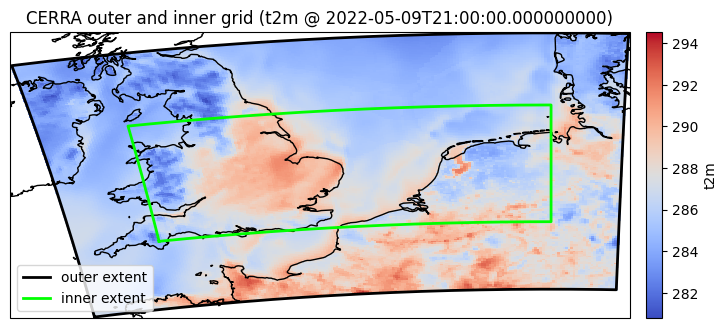

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Helper to get the outline of a grid
def _outline_coords(ds):
    lat = ds['latitude'].values
    lon = ds['longitude'].values
    edge_lat = np.concatenate([lat[0, :], lat[:, -1], lat[-1, ::-1], lat[::-1, 0]])
    edge_lon = np.concatenate([lon[0, :], lon[:, -1], lon[-1, ::-1], lon[::-1, 0]])
    return edge_lon, edge_lat

# Select t2m and a random time slice
t2m = outer['t2m']
t2m_inner = inner['t2m']

if 'time' in t2m.dims:
    t_idx = np.random.randint(t2m.sizes['time'])
    data_var = t2m.isel(time=t_idx)
    data_inner = t2m_inner.isel(time=t_idx)
    timestamp = str(t2m['time'].isel(time=t_idx).values)
else:
    data_var = t2m
    data_inner = t2m_inner
    timestamp = 'static'

# Compute outer and inner outlines
out_lon, out_lat = _outline_coords(data_var)
in_lon, in_lat = _outline_coords(data_inner)

# Create figure and main axes
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot without automatic colorbar
pcm = data_var.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    x='longitude',
    y='latitude',
    add_colorbar=False   # <-- important
)

# Add outlines
ax.plot(out_lon, out_lat, color='black', linewidth=2,
        transform=ccrs.PlateCarree(), label='outer extent')
ax.plot(in_lon, in_lat, color='lime', linewidth=2,
        transform=ccrs.PlateCarree(), label='inner extent')

ax.coastlines()
ax.legend(loc='lower left')
ax.set_title(f'CERRA outer and inner grid (t2m @ {timestamp})')

# Make colorbar axis that matches the height of the map
pos = ax.get_position()  # Bbox: [x0, y0, width, height] in figure coords
cbar_width = 0.02

cax = fig.add_axes([
    pos.x1 + 0.02,   # a bit to the right of the map
    pos.y0,          # align bottom
    cbar_width,      # width
    pos.height       # EXACT same height as the map
])

cb = plt.colorbar(pcm, cax=cax)
cb.set_label('t2m')

plt.show()

